<div dir="rtl">

# מטלה 2 — טיפול בנתונים חסרים, מודל פרוגנוסטי ודירוג סיכונים

**דאטה:** MIMIC Demo | **מטרה:** Prolonged ICU Stay (שהייה ב-ICU באחוזון 75 ומעלה).

## עקרונות מתודולוגיים (מנחים את כל המחברת)
- **מניעת דליפה:** כל השלמה/סקיילינג/קידוד נלמדים על ה-train בלבד בתוך `Pipeline`, ומוחלים על ה-test.
- `icu_los` והמזהים מושמטים מהפיצ'רים — `icu_los` מגדיר את המטרה.
- **שחזוריות:** `SEED=42` קבוע בכל מקום (פיצול, יצירת חוסר, מודלים).
- **גרפים:** תוויות באנגלית כדי שהעברית לא תתהפך; כל הניתוח המילולי בעברית בטבלאות וב-Markdown.

</div>

In [5]:
# === תא 0: הגדרות, טעינה ועזרי תצוגה ===
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "grid.alpha": 0.3})

DATA_FILENAME = "MIMIC_data_demo.xlsx"
RAW_URL = ("https://raw.githubusercontent.com/Roybin12/"
           "medical-machine-learning-/main/MIMIC_data_demo.xlsx")

def find_data_path(filename=DATA_FILENAME, max_up=5):
    here = Path.cwd().resolve()
    for folder in [here, *here.parents][:max_up + 1]:
        if (folder / filename).exists():
            return folder / filename
    return None

def load_raw_data():
    """טוען מה-repo המקומי; אם לא נמצא — נופל ל-GitHub raw. רץ מכל מחשב."""
    path = find_data_path()
    return pd.read_excel(path if path is not None else RAW_URL)

def rtl(df):
    """מציג DataFrame בכיוון ימין-לשמאל (קריא בעברית)."""
    sty = df.style.set_table_styles(
        [{"selector": "", "props": [("direction", "rtl")]},
         {"selector": "th, td", "props": [("text-align", "right")]}])
    try:
        sty = sty.hide(axis="index")
    except Exception:
        pass
    return sty

df_raw = load_raw_data()
display(rtl(pd.DataFrame({"שורות": [df_raw.shape[0]], "עמודות": [df_raw.shape[1]]})))

שורות,עמודות
4559,57


<div dir="rtl">

## שלב 1 — יצירת משתנה המטרה (Outcome)

**הגדרה:** `prolonged_icu = 1` אם `icu_los` ≥ אחוזון 75, אחרת 0.
**החלטה:** בוחרים 13 משתנים תואמי-מטלה ומשמיטים `icu_los` והמזהים מהפיצ'רים (מניעת דליפה).

</div>

מדד,ערך
סף icu_los (אחוזון 75),5.865 ימים
"סה""כ רשומות",4559
חיוביים (n+),1140
שליליים,3419
אחוז חיוביים,25.0%


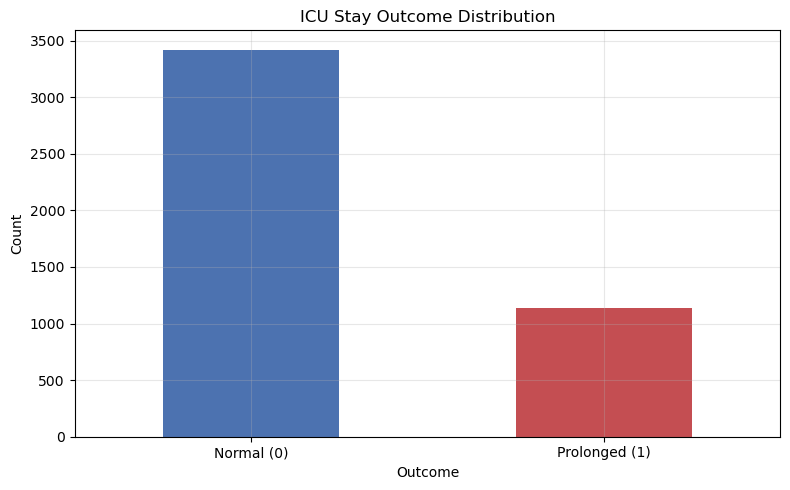

In [6]:
# === שלב 1: משתנה המטרה ובחירת פיצ'רים ===
rename_map = {
    "age": "age", "gender": "gender", "ethnicity": "ethnicity",
    "first_service": "service_first", "vent": "vent",
    "heartrate_mean": "mean_heartrate", "sysbp_mean": "mean_sysbp",
    "resprate_mean": "mean_resprate", "tempc_mean": "mean_tempc",
    "spo2_mean": "mean_spo2", "glucose_mean": "mean_glucose",
    "creatinine_max": "max_creatinine", "wbc_mean": "mean_wbc",
}
FEATURES = list(rename_map.values())

TARGET_PCTL = 0.75
los_threshold = df_raw["icu_los"].quantile(TARGET_PCTL)
df = df_raw.rename(columns=rename_map)[FEATURES].copy()
df["prolonged_icu"] = (df_raw["icu_los"] >= los_threshold).astype(int)

n_total = len(df); n_pos = int(df["prolonged_icu"].sum())
target_summary = pd.DataFrame({
    "מדד": ["סף icu_los (אחוזון 75)", "סה\"כ רשומות", "חיוביים (n+)",
            "שליליים", "אחוז חיוביים"],
    "ערך": [f"{los_threshold:.3f} ימים", n_total, n_pos,
            n_total - n_pos, f"{n_pos / n_total * 100:.1f}%"],
})
display(rtl(target_summary))

# גרף — תוויות באנגלית
counts = df["prolonged_icu"].value_counts().sort_index()
ax = counts.plot(kind="bar", color=["#4C72B0", "#C44E52"], rot=0)
ax.set_title("ICU Stay Outcome Distribution")
ax.set_xlabel("Outcome"); ax.set_ylabel("Count")
ax.set_xticklabels(["Normal (0)", "Prolonged (1)"])
plt.tight_layout(); plt.show()

<div dir="rtl">

**שאלה 1 — האם קיים חוסר איזון?**
כן, חוסר איזון מתון: ~25% חיוביים מול ~75% שליליים (נובע מהגדרת המטרה כרבע העליון).
נטפל בכך ע"י פיצול מרובד (stratify), `class_weight`, ודגש על PR-AUC ולא רק ROC-AUC.

</div>

<div dir="rtl">

## שלב 2 — יצירת נתונים חסרים (מלאכותיים)

שומרים עותק אמת (`df_original`) לפני ההחסרה, ומחסירים רק תאים שכרגע **קיימים** (כדי שתהיה אמת להשוואה בשלב 5).
- `mean_heartrate`: 10% אקראי → **MCAR**.
- `max_creatinine`: גיל<70 → 30% חסר ; גיל≥70 → 5% חסר → **MAR** (תלוי בגיל הנצפה).
שומרים מסכות של התאים שהוחסרו מלאכותית בלבד.

</div>

In [7]:
# === שלב 2: הזרקת חוסר מבוקר ===
rng = np.random.default_rng(SEED)
df_original = df.copy()      # אמת — לפני ההחסרה
df_missing = df.copy()       # עליו נעבוד מכאן והלאה

# (א) mean_heartrate — MCAR 10% מהתאים הקיימים
hr_obs = df_missing.index[df_missing["mean_heartrate"].notna()]
hr_sel = rng.choice(hr_obs, size=int(round(0.10 * len(hr_obs))), replace=False)
df_missing.loc[hr_sel, "mean_heartrate"] = np.nan

# (ב) max_creatinine — MAR לפי גיל
for age_mask, rate in [(df_missing["age"] < 70, 0.30),
                       (df_missing["age"] >= 70, 0.05)]:
    grp = df_missing.index[age_mask & df_missing["max_creatinine"].notna()]
    sel = rng.choice(grp, size=int(round(rate * len(grp))), replace=False)
    df_missing.loc[sel, "max_creatinine"] = np.nan

# מסכות של תאים שהוחסרו מלאכותית בלבד (קיים באמת אך NaN עכשיו)
artif_mask = {c: df_original[c].notna() & df_missing[c].isna()
              for c in ["mean_heartrate", "max_creatinine"]}

summary = pd.DataFrame({
    "משתנה": ["mean_heartrate", "max_creatinine"],
    "תאים שהוחסרו": [int(artif_mask["mean_heartrate"].sum()),
                     int(artif_mask["max_creatinine"].sum())],
    "אחוז חוסר מלאכותי": [f"{artif_mask['mean_heartrate'].mean() * 100:.1f}%",
                          f"{artif_mask['max_creatinine'].mean() * 100:.1f}%"],
    "מנגנון": ["MCAR", "MAR (תלוי גיל)"],
    "נימוק": ["אקראי לחלוטין — לא תלוי בשום משתנה",
              "הסתברות החוסר תלויה בגיל הנצפה (גבוה מתחת ל-70)"],
})
display(rtl(summary))

# חוסר כולל (טבעי + מלאכותי) — כטבלה
total_missing = (df_missing[["mean_heartrate", "max_creatinine"]]
                 .isna().mean().mul(100).round(2)
                 .reset_index())
total_missing.columns = ["משתנה", "אחוז חוסר כולל"]
display(rtl(total_missing))

משתנה,תאים שהוחסרו,אחוז חוסר מלאכותי,מנגנון,נימוק
mean_heartrate,456,10.0%,MCAR,אקראי לחלוטין — לא תלוי בשום משתנה
max_creatinine,885,19.4%,MAR (תלוי גיל),הסתברות החוסר תלויה בגיל הנצפה (גבוה מתחת ל-70)


משתנה,אחוז חוסר כולל
mean_heartrate,10.000000
max_creatinine,19.460000


<div dir="rtl">

**שאלה 2 — האם מנגנון החוסר השפיע על בחירת ההשלמה?**
כן. ב-MCAR (heartrate) כמעט כל שיטה נותנת אומדן בלתי-מוטה.
ב-MAR (creatinine, תלוי גיל) השלמת ממוצע מטה את הערכים, ואילו MICE מתנה על הגיל ולכן צפויה להתאים טוב יותר.

</div>